# Load Data

In [ ]:
!pip install wandb

In [ ]:
!pip install datasets

In [ ]:
!pip install underthesea

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud
from underthesea import pos_tag
from difflib import SequenceMatcher
from collections import Counter
from transformers import Trainer, TrainingArguments, AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score,precision_score,recall_score, classification_report
import torch
import os
from datasets import Dataset, DatasetDict, load
from sklearn.model_selection import train_test_split
from collections import defaultdict
from joblib import Parallel, delayed

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/[DS201 + DS310] ĐỒ ÁN/[DS201 + DS310] BÀI NỘP/ViLawDocsNLI.xlsx')

In [ ]:
df.head(3)

,Hypothesis,Premise,Text,Aspect,Website,Label,List Evidence,Explanation,File Path,Text Length
0,Cơ quan kho bạc nhà nước phải thực hiện việc t...,4. Cơ quan kho bạc nhà nước có trách nhiệm a T...,QUYẾT ĐỊNH QUY ĐỊNH VỀ MỨC THU TIỀN SỬ DỤNG KH...,tài chính nhà nước,https://thuvienphapluat.vn/,0,"""Không được chuyển việc thu tiền sang ngày hôm...",Bằng chứng chỉ ra rõ ràng rằng cơ quan kho bạc...,/content/drive/MyDrive/[DS201 + DS310] ĐỒ Á...,2232
1,Quyết định này có thể đến từ một sự thay đổi t...,4. Cơ quan kho bạc nhà nước có trách nhiệm a T...,QUYẾT ĐỊNH QUY ĐỊNH VỀ MỨC THU TIỀN SỬ DỤNG KH...,tài chính nhà nước,https://thuvienphapluat.vn/,1,NaN,Nội dung không đề cập đến lý do cụ thể tại sao...,/content/drive/MyDrive/[DS201 + DS310] ĐỒ Á...,2232
2,Ủy ban nhân dân huyện Cần Giờ không có trách n...,4. Cơ quan kho bạc nhà nước có trách nhiệm a T...,QUYẾT ĐỊNH QUY ĐỊNH VỀ MỨC THU TIỀN SỬ DỤNG KH...,tài chính nhà nước,https://thuvienphapluat.vn/,2,"""Ủy ban nhân dân huyện Cần Giờ có trách nhiệm ...",Bằng chứng cho thấy rõ ràng rằng Ủy ban nhân d...,/content/drive/MyDrive/[DS201 + DS310] ĐỒ Á...,2232


In [ ]:
def split_data(df, test_size=0.1, dev_size=0.1):
    grouped = list(df.groupby('Text'))
    train_groups, temp_groups = train_test_split(grouped, test_size=(test_size + dev_size), random_state=42)
    dev_size_adjusted = dev_size / (test_size + dev_size)
    dev_groups, test_groups = train_test_split(temp_groups, test_size=1 - dev_size_adjusted, random_state=42)
    def flatten(groups):
        return pd.concat([group for _, group in groups])
    train_df = flatten(train_groups)
    dev_df = flatten(dev_groups)
    test_df = flatten(test_groups)
    return train_df, dev_df, test_df

# EDA

In [ ]:
print('Các cột của dữ liệu:')
df.columns

Các cột của dữ liệu:


Index(['Hypothesis', 'Premise', 'Text', 'Aspect', 'Website', 'Label',
       'List Evidence', 'Explanation', 'File Path', 'Text Length'],
      dtype='object')

In [ ]:
df.shape

(9696, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9696 entries, 0 to 9695
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Hypothesis     9683 non-null   object
 1   Premise        9672 non-null   object
 2   Text           9696 non-null   object
 3   Aspect         9696 non-null   object
 4   Website        9696 non-null   object
 5   Label          9696 non-null   int64 
 6   List Evidence  6455 non-null   object
 7   Explanation    9683 non-null   object
 8   File Path      9696 non-null   object
 9   Text Length    9696 non-null   int64 
dtypes: int64(2), object(8)
memory usage: 757.6+ KB


In [ ]:
df['Text Length'].describe()

,Text Length
count,9696.000000
mean,2379.910994
std,2144.164501
min,33.000000
25%,828.000000
50%,1361.000000
75%,3431.000000
max,8285.000000


In [ ]:
# Kiểm tra giá trị trùng nhau
print('Số giá trị trùng nhau của bộ dữ liệu:',df.duplicated().sum())

Số giá trị trùng nhau của bộ dữ liệu: 0


In [ ]:
def missing_values_table(df):
    if df.isnull().sum().any():
        print('Số giá trị khuyết của bộ dữ liệu:')
        print(df.isnull().sum())
    else:
        print('Bộ dữ liệu không có giá trị khuyết')

In [ ]:
missing_values_table(df)

Số giá trị khuyết của bộ dữ liệu:
Hypothesis         13
Premise            24
Text                0
Aspect              0
Website             0
Label               0
List Evidence    3241
Explanation        13
File Path           0
Text Length         0
dtype: int64


In [ ]:
# Xử lý giá trị khuyết
df.dropna(subset = ['Premise', 'Hypothesis', 'Explanation'], inplace = True)

In [ ]:
df.shape

(9667, 10)

In [ ]:
missing_values_table(df)

Số giá trị khuyết của bộ dữ liệu:
Hypothesis          0
Premise             0
Text                0
Aspect              0
Website             0
Label               0
List Evidence    3223
Explanation         0
File Path           0
Text Length         0
dtype: int64


In [ ]:
# Hàm đếm số từ trong câu
def count_words(sentence):
    return len(sentence.split())

# Đếm số từ trong từng câu của cột 'Premise' và 'Hypothesis'
df['Premise_Length'] = df['Premise'].apply(count_words)
df['Hypothesis_Length'] = df['Hypothesis'].apply(count_words)

In [ ]:
train_df, dev_df, test_df = split_data(df)

In [ ]:
def create_hypothesis_table(train, dev, test, group_by):
    # Tính tổng số từ
    train_count = train.groupby(group_by).agg({'Hypothesis_Length': 'sum'}).rename(columns={'Hypothesis_Length': 'Hypothesis_Train'})
    dev_count = dev.groupby(group_by).agg({'Hypothesis_Length': 'sum'}).rename(columns={'Hypothesis_Length': 'Hypothesis_Dev'})
    test_count = test.groupby(group_by).agg({'Hypothesis_Length': 'sum'}).rename(columns={'Hypothesis_Length': 'Hypothesis_Test'})

    # Hợp nhất
    merged = train_count.merge(dev_count, left_index=True, right_index=True)
    merged = merged.merge(test_count, left_index=True, right_index=True)
    merged['Total'] = merged.sum(axis=1)

    return merged.reset_index()

In [ ]:
# Tạo bảng Hypothesis cho Aspect và Label
hypothesis_aspect_table = create_hypothesis_table(train_df, dev_df, test_df, 'Aspect')
hypothesis_label_table = create_hypothesis_table(train_df, dev_df, test_df, 'Label')

In [ ]:
hypothesis_aspect_df = pd.DataFrame(hypothesis_aspect_table)
hypothesis_label_df = pd.DataFrame(hypothesis_label_table)

print("Hypothesis Table (Aspect):")
hypothesis_aspect_df

Hypothesis Table (Aspect):


,Aspect,Hypothesis_Train,Hypothesis_Dev,Hypothesis_Test,Total
0,bất động sản,4800,645,679,6124
1,bộ máy hành chính,67409,9349,8702,85460
2,chứng khoán,1227,193,186,1606
3,công nghệ thông tin,4164,738,527,5429
4,doanh nghiệp,1375,319,173,1867
5,dân sự,7071,1660,651,9382
6,giao thông - vận tải,12018,724,974,13716
7,giáo dục,10821,692,1554,13067
8,khác,15501,1912,2396,19809
9,kế toán - kiểm toán,715,266,363,1344


In [ ]:
print("\nHypothesis Table (Label):")
hypothesis_label_df


Hypothesis Table (Label):


,Label,Hypothesis_Train,Hypothesis_Dev,Hypothesis_Test,Total
0,0,77274,10190,9842,97306
1,1,62526,8174,7897,78597
2,2,59342,7770,7488,74600


In [ ]:
sum_train = train_df['Hypothesis_Length'].sum()
sum_dev = dev_df['Hypothesis_Length'].sum()
sum_test = test_df['Hypothesis_Length'].sum()
sum_total = df['Hypothesis_Length'].sum()
print('Total')
print(f'Train: {sum_train}')
print(f'Dev: {sum_dev}')
print(f'Test: {sum_test}')
print(f'Data: {sum_total}')

Total
Train: 199142
Dev: 26134
Test: 25227
Data: 250503


In [ ]:
# Tính MHL cho từng tập dữ liệu
mhl_train = train_df['Hypothesis_Length'].mean()
mhl_dev = dev_df['Hypothesis_Length'].mean()
mhl_test = test_df['Hypothesis_Length'].mean()
mhl_total = df['Hypothesis_Length'].mean()

print(f"MHL - Train: {mhl_train}")
print(f"MHL - Dev: {mhl_dev}")
print(f"MHL - Test: {mhl_test}")
print(f"MHL - Data: {mhl_total}")

MHL - Train: 25.892861786503705
MHL - Dev: 25.84965380811078
MHL - Test: 26.141968911917097
MHL - Data: 25.91320988931416


In [ ]:
# Tính MPL cho từng tập dữ liệu
mpl_train = train_df['Premise_Length'].mean()
mpl_dev = dev_df['Premise_Length'].mean()
mpl_test = test_df['Premise_Length'].mean()
mpl_total = df['Premise_Length'].mean()

print(f"MPL - Train: {mpl_train}")
print(f"MPL - Dev: {mpl_dev}")
print(f"MPL - Test: {mpl_test}")
print(f"MPL - Data: {mpl_total}")

MPL - Train: 423.7845533740736
MPL - Dev: 420.21958456973294
MPL - Test: 426.06321243523314
MPL - Data: 423.6391848556946


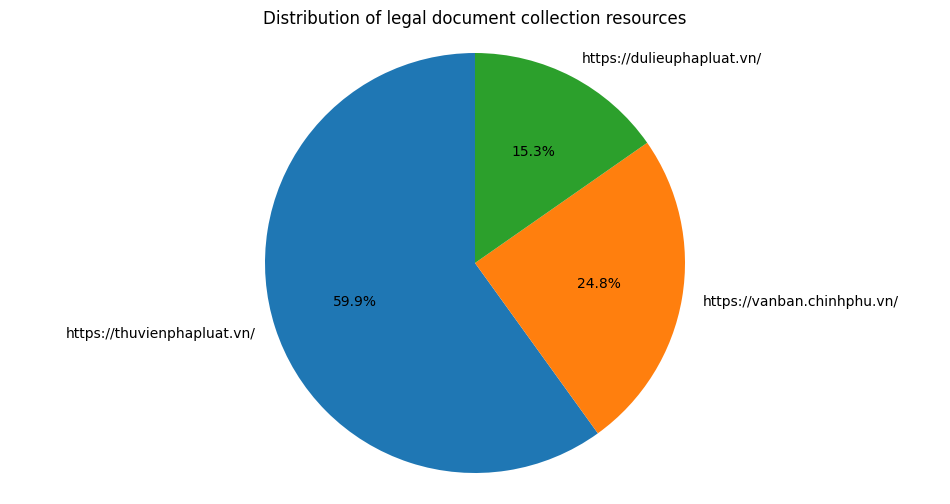

In [ ]:
website_counts = df['Website'].value_counts()

plt.figure(figsize=(12, 6))
plt.pie(website_counts, labels=website_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Distribution of legal document collection resources")
plt.axis('equal')
plt.show()

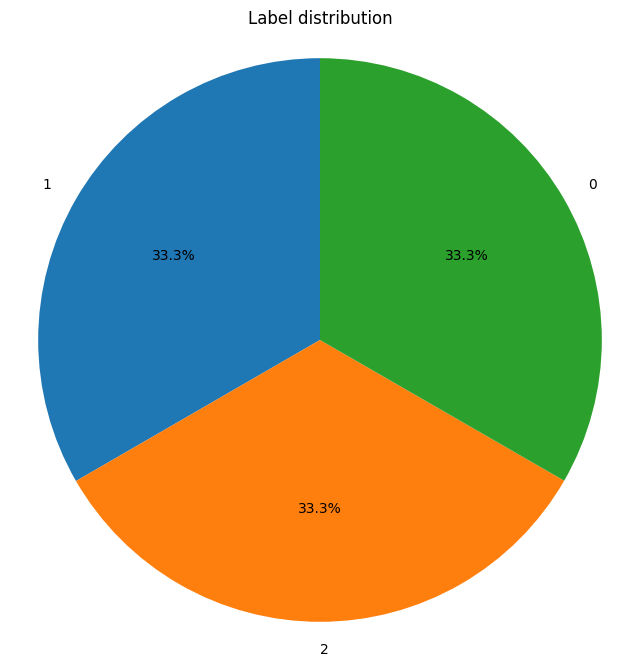

In [ ]:
# Phân phối nhãn
label_counts = df['Label'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Label distribution')
plt.axis('equal')
plt.show()

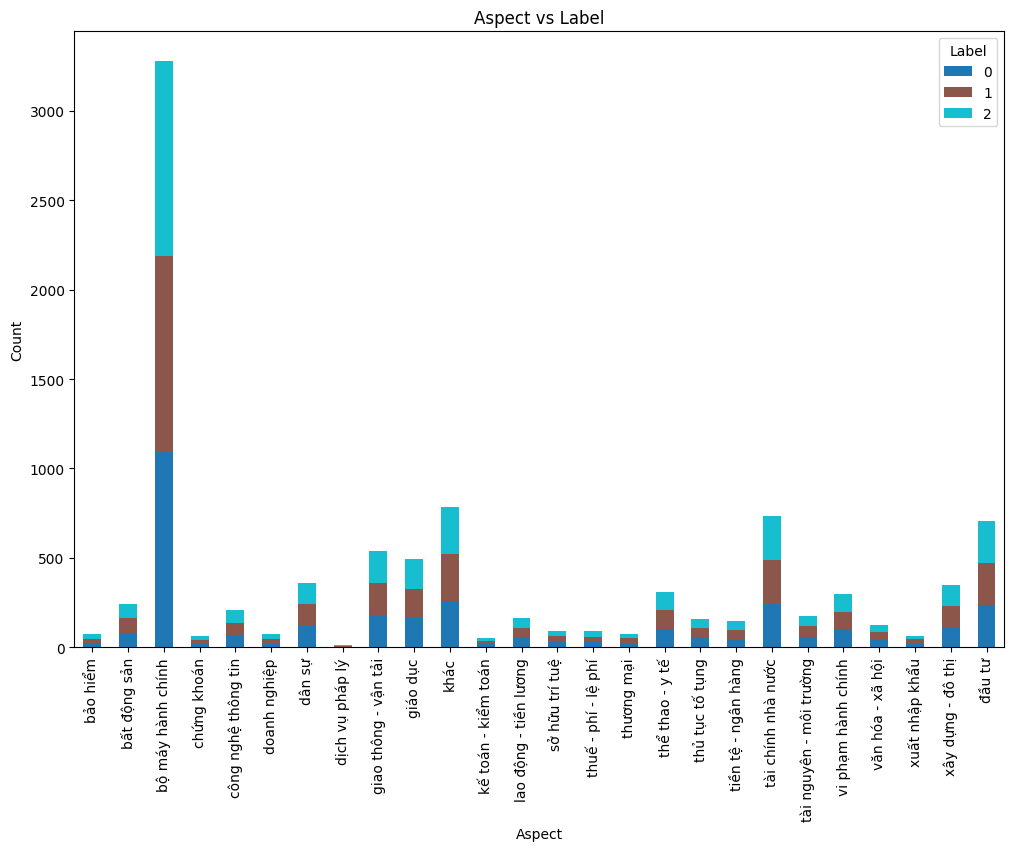

In [ ]:
# Mối quan hệ giữa label và aspect
aspect_label_counts = df.groupby(['Aspect', 'Label']).size().unstack()
aspect_label_counts.plot(kind='bar', stacked=True, figsize=(12, 8), cmap='tab10')
plt.title("Aspect vs Label")
plt.ylabel("Count")
plt.xlabel("Aspect")
plt.show()

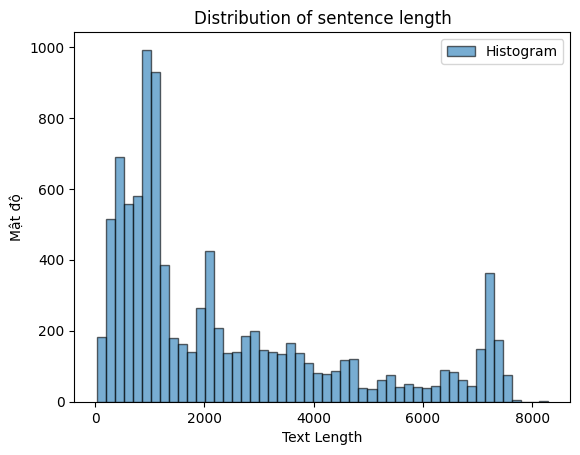

In [ ]:
plt.hist(df['Text Length'], bins=50, edgecolor='black', alpha=0.6, label="Histogram")

plt.xlabel('Text Length')
plt.ylabel('Mật độ')
plt.title("Distribution of sentence length")
plt.legend()
plt.show()

Tổng giá trị của các chủ đề duy nhất: 26 



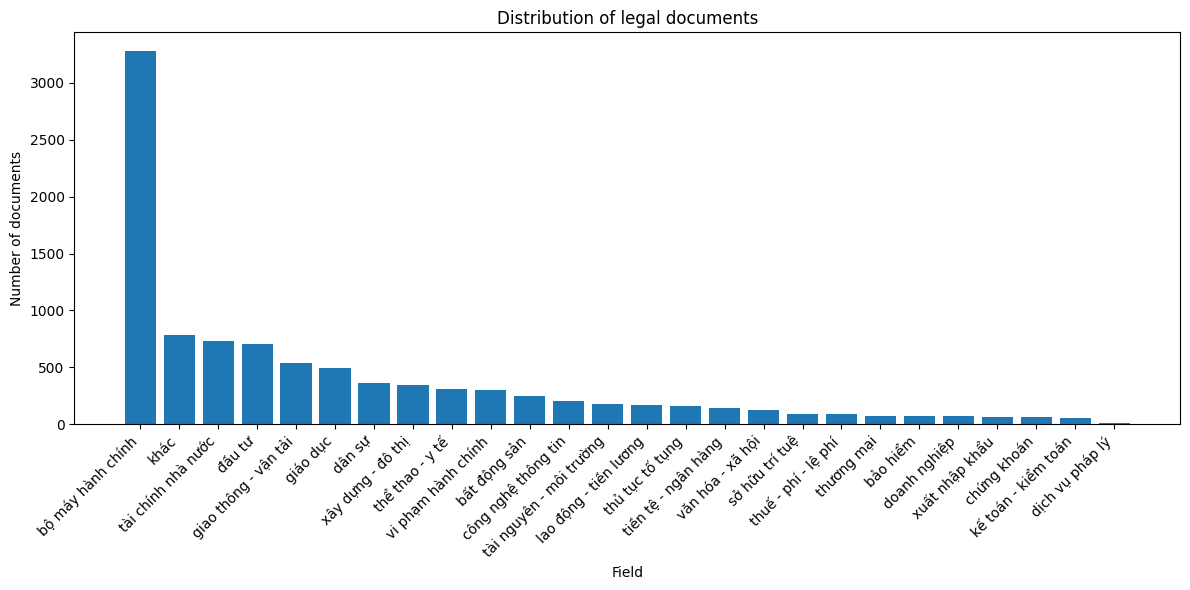

In [ ]:
# Phân phối lĩnh vực văn bản luật
print('Tổng giá trị của các chủ đề duy nhất:', df['Aspect'].nunique(),'\n')
aspect_counts = df['Aspect'].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(aspect_counts.index, aspect_counts.values)
plt.xlabel("Field")
plt.ylabel("Number of documents")
plt.title("Distribution of legal documents")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# World Cloud
def plot_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(text))
    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

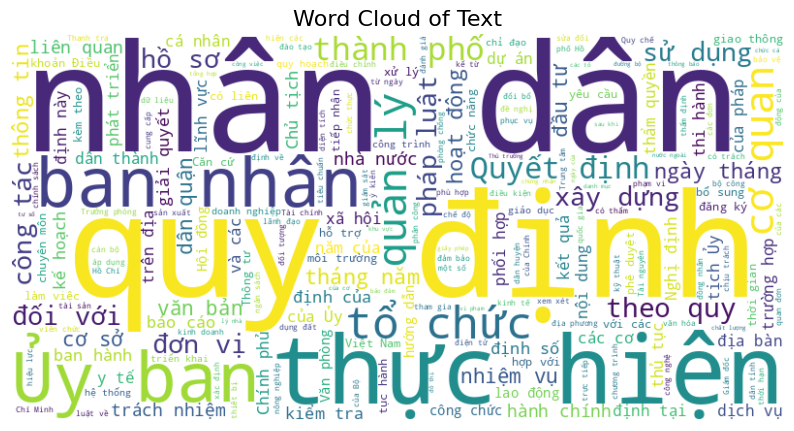

In [ ]:
plot_wordcloud(df['Text'], "Word Cloud of Text")

In [ ]:
# N-gram Analysis
def plot_ngrams(text, n=2, top_k=20):
    vectorizer = CountVectorizer(ngram_range=(n, n))
    ngrams = vectorizer.fit_transform(text)
    ngram_counts = ngrams.sum(axis=0)
    ngram_freq = [(word, ngram_counts[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    ngram_freq = sorted(ngram_freq, key=lambda x: x[1], reverse=True)[:top_k]

    ngram_df = pd.DataFrame(ngram_freq, columns=['N-gram', 'Frequency'])
    sns.barplot(data=ngram_df, x='Frequency', y='N-gram', palette='viridis')
    plt.title(f'Top {top_k} {n}-grams')
    plt.show()

<ipython-input-36-3b55f212e673>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ngram_df, x='Frequency', y='N-gram', palette='viridis')


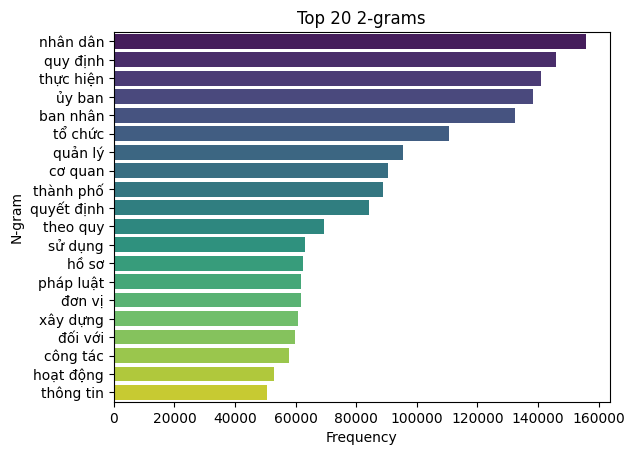

In [ ]:
plot_ngrams(df['Text'], n=2, top_k=20)

In [ ]:
def jaccard_similarity(set1, set2):
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union if union != 0 else 0

In [ ]:
def new_word_rate(set1, set2):
    new_words = len(set2 - set1)
    return new_words / len(set2) if len(set2) != 0 else 0

In [ ]:
def longest_common_subsequence(str1, str2):
    seq_matcher = SequenceMatcher(None, str1, str2)
    return seq_matcher.find_longest_match(0, len(str1), 0, len(str2)).size

In [ ]:
def pos_distribution(text):
    pos_tags = pos_tag(text)
    pos_counts = Counter(tag for _, tag in pos_tags)
    total = sum(pos_counts.values())
    return {pos: (count / total) * 100 for pos, count in pos_counts.items()}

In [ ]:
jaccard_scores = []
new_word_rates = []
lcs_scores = []
pos_distributions = []

In [ ]:
for _, row in df.iterrows():
    premise = str(row['Premise'])
    hypothesis = str(row['Hypothesis'])

    premise_words = set(premise.split())
    hypothesis_words = set(hypothesis.split())

    # Tính toán Jaccard và Tỷ lệ từ mới
    jaccard_scores.append(jaccard_similarity(premise_words, hypothesis_words))
    new_word_rates.append(new_word_rate(premise_words, hypothesis_words))

    # Tính toán LCS
    lcs_scores.append(longest_common_subsequence(premise, hypothesis))

    # Tính toán phân phối POS
    pos_distributions.append(pos_distribution(hypothesis))

In [ ]:
data_summary = pd.DataFrame({
    'Label': df['Label'],
    'Jaccard': jaccard_scores,
    'New Word Rate': new_word_rates,
    'LCS': lcs_scores,
    'POS Distribution': pos_distributions
})

In [ ]:
# Trích xuất phần trăm POS riêng lẻ
pos_tags = ["N", "V", "A", "P", "R", "X"]
for pos in pos_tags:
    data_summary[f"POS_{pos}"] = data_summary['POS Distribution'].apply(lambda x: x.get(pos, 0))

In [ ]:
summary = data_summary.groupby('Label').agg({
    'Jaccard': 'mean',
    'New Word Rate': 'mean',
    'LCS': 'mean',
    **{f"POS_{pos}": "mean" for pos in pos_tags}
}).reset_index()

In [ ]:
summary = summary.rename(columns={
    "POS_N": "Danh từ",
    "POS_V": "Động từ",
    "POS_A": "Tính từ",
    "POS_P": "Đại từ",
    "POS_R": "Phó từ",
    "POS_X": "Khác"
})

In [ ]:
summary

,Label,Jaccard,New Word Rate,LCS,Danh từ,Động từ,Tính từ,Đại từ,Phó từ,Khác
0,0,0.108432,0.260612,34.004036,36.879959,26.712625,4.241166,0.788143,3.309566,0.021528
1,1,0.074237,0.387026,27.660565,36.293087,24.357164,3.805218,1.615545,7.161334,0.018154
2,2,0.082238,0.293001,28.923984,34.723138,24.827583,3.255743,2.843682,8.291527,0.005205


# Training

## Xây dựng pipeline

In [ ]:
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer

def load_and_preprocess_data(train_df, dev_df, test_df, tokenizer):
    def preprocess_function(examples):
        # Mã hóa Hypothesis và Premise
        tokenized = tokenizer(
            examples['Hypothesis'],  # Tên cột Hypothesis trong DataFrame
            examples['Premise'],     # Tên cột Premise trong DataFrame
            truncation=True,
            padding='max_length',
            max_length=512,         # Chỉnh sửa kích thước nếu cần
            return_tensors= 'pt'    # Loại bỏ return_tensors="pt" vì Trainer yêu cầu danh sách/mảng
        )
        tokenized['labels'] = examples['Label']  # Gán nhãn vào cột labels
        return tokenized

    # Chuyển DataFrame thành Dataset
    train_dataset = Dataset.from_pandas(train_df)
    dev_dataset = Dataset.from_pandas(dev_df)
    test_dataset = Dataset.from_pandas(test_df)

    # Áp dụng tiền xử lý và mã hóa dữ liệu
    encoded_train_dataset = train_dataset.map(lambda x: preprocess_function(x), batched=True)
    encoded_dev_dataset = dev_dataset.map(lambda x: preprocess_function(x), batched=True)
    encoded_test_dataset = test_dataset.map(lambda x: preprocess_function(x), batched=True)

    # Trả về DatasetDict chứa các dataset đã mã hóa
    return DatasetDict({
        "train": encoded_train_dataset,
        "dev": encoded_dev_dataset,
        "test": encoded_test_dataset
    })

In [ ]:
def compute_metrics(pred):
    predictions, labels = pred
    predictions = np.argmax(predictions, axis=1)

    acc = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, average='macro', zero_division=1)  # Precision (macro-average)
    recall = recall_score(labels, predictions, average='macro', zero_division=1)  # Recall (macro-average)
    f1 = f1_score(labels, predictions, average='macro')
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
def train_and_evaluate(model_name, dataset, num_labels=3):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

    training_args = TrainingArguments(
        output_dir=f"./results/{model_name.replace('/', '_')}",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        num_train_epochs=5,
        weight_decay=0.01,
        logging_dir=f"./logs/{model_name.replace('/', '_')}",
        logging_steps=10,
        load_best_model_at_end=True,
    )
    os.environ["WANDB_DISABLED"] = "true"
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=dataset['train'],
        eval_dataset=dataset['dev'],
        compute_metrics=compute_metrics,
    )

    trainer.train()
    torch.cuda.empty_cache()

    dev_results = trainer.evaluate(dataset['dev'])
    test_results = trainer.evaluate(dataset['test'])

    # Trả về một từ điển với kết quả đánh giá
    return {
        'model_name': model_name,
        'dev_accuracy': dev_results['eval_accuracy'],
        'dev_f1': dev_results['eval_f1'],
        'test_accuracy': test_results['eval_accuracy'],
        'test_f1': test_results['eval_f1'],
        'trainer': trainer,
        'model': model
    }

In [ ]:
# Hàm so sánh giữa các mô hình
def compare_models(models, dataset):
    results = []

    for model_name in models:
        print(f"Đang huấn luyện và đánh giá mô hình: {model_name}")
        result = train_and_evaluate(model_name, dataset)
        results.append(result)

    # Chuyển kết quả thành DataFrame để dễ dàng hiển thị
    df_results = pd.DataFrame(results)

    # In ra bảng so sánh
    print("\nSo sánh kết quả giữa các mô hình:")
    print(df_results)

In [ ]:
# Đánh giá theo từng label
def evaluate_per_label(labels, predictions):
    report = classification_report(labels, predictions, target_names=["Label 0", "Label 1", "Label 2"])  # Cập nhật tên label nếu cần
    print("Đánh giá theo từng label:\n", report)

In [ ]:
def evaluate_per_aspect(df, predictions):
    # Kiểm tra và chuyển đổi `Dataset` sang pandas DataFrame nếu cần
    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    # Thêm cột 'Predicted' vào DataFrame
    df['Predicted'] = predictions

    # Duyệt qua các 'Aspect' trong df
    for aspect in df['Aspect'].unique():
        aspect_data = df[df['Aspect'] == aspect]

        # Kiểm tra dữ liệu
        true_labels = aspect_data['Label'].values
        predicted_labels = aspect_data['Predicted'].values

        # In báo cáo phân loại với F1-score theo macro
        report = classification_report(true_labels, predicted_labels, target_names=["Label 0", "Label 1", "Label 2"])
        print(f"Đánh giá cho Aspect - {aspect}:\n", report)

In [ ]:
def evaluate_by_length(predictions, labels, hypothesis_lengths):
    # Chia các câu thành nhóm theo chiều dài và tính accuracy và f1-score cho mỗi nhóm
    bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]  # Điều chỉnh bins theo yêu cầu
    labels_binned = pd.cut(hypothesis_lengths, bins)

    # Tính độ chính xác và F1-score cho mỗi nhóm
    for length_bin in labels_binned.unique():
        indices = [i for i, length in enumerate(hypothesis_lengths) if labels_binned[i] == length_bin]
        length_preds = [predictions[i] for i in indices]
        length_labels = [labels[i] for i in indices]

        # Kiểm tra số lớp trong length_labels và length_preds
        unique_labels = np.unique(length_labels)
        print(f"Số lớp trong nhóm chiều dài {length_bin}: {unique_labels}")

        # Đảm bảo các lớp trong dữ liệu của bạn khớp với target_names
        report = classification_report(length_labels, length_preds, target_names=["Label 0", "Label 1", "Label 2"], labels=np.unique(length_labels))
        print(f"Đánh giá cho chiều dài {length_bin}:\n", report)

In [ ]:
def save_predictions(predictions, labels, filename="predictions.csv"):
    # Lưu kết quả dự đoán vào CSV
    df_predictions = pd.DataFrame({
        "Prediction": predictions,
        "True Label": labels,
    })
    df_predictions.to_csv(filename, index=False)
    print(f"Saved predictions to {filename}")

In [ ]:
def get_predictions(trainer, dev_predictions, test_predictions):
    # Dự đoán trên dev dataset
    dev_preds = np.argmax(dev_predictions.predictions, axis=1)
    dev_labels = dev_predictions.label_ids
    print("\n________ĐÁNH GIÁ TRÊN TẬP DEV________")

    # Đánh giá cho dev
    print("Đánh giá cho dev:")
    evaluate_per_label(dev_labels, dev_preds)
    dev_metrics = compute_metrics((dev_predictions.predictions, dev_labels))
    print("Metrics trên dev:", dev_metrics)

    # Đánh giá theo từng Aspect trên dev
    print("\nĐánh giá theo từng Aspect trên dev:")
    evaluate_per_aspect(dev_df, dev_preds)


    # Đánh giá theo chiều dài câu trên dev
    print("\nĐánh giá theo từng Hypothesis Length trên dev:")
    hypothesis_lengths_dev = dev_df['Hypothesis_Length'].tolist()
    evaluate_by_length(dev_preds, dev_labels, hypothesis_lengths_dev)

    # Dự đoán trên test dataset
    test_preds = np.argmax(test_predictions.predictions, axis=1)
    test_labels = test_predictions.label_ids
    print("\n\n________ĐÁNH GIÁ TRÊN TẬP TEST________")

    # Đánh giá cho test
    print("Đánh giá cho test:")
    evaluate_per_label(test_labels, test_preds)
    test_metrics = compute_metrics((test_predictions.predictions, test_labels))
    print("Metrics trên test:", test_metrics)

    # Đánh giá theo từng Aspect trên test
    print("\nĐánh giá theo từng Aspect trên test:")
    evaluate_per_aspect(test_df, test_preds)

    # Đánh giá theo chiều dài câu trên test
    print("\nĐánh giá theo từng Hypothesis Length trên test:")
    hypothesis_lengths_test = test_df['Hypothesis_Length'].tolist()
    evaluate_by_length(test_preds, test_labels, hypothesis_lengths_test)

## Training

In [ ]:
models = ["bert-base-multilingual-cased", "vinai/phobert-large", "xlm-roberta-large", "nguyenvulebinh/cafebert"]

### BertBase

In [ ]:
model_name = models[0]
tokenizer = AutoTokenizer.from_pretrained(model_name)
dataset = load_and_preprocess_data(train_df, dev_df, test_df, tokenizer)
print(f"Đang huấn luyện mô hình: {model_name}")
evaluation_results = train_and_evaluate(model_name, dataset)
trainer = evaluation_results['trainer']
model = evaluation_results['model']

Map:   0%|          | 0/7691 [00:00<?, ? examples/s]

Map:   0%|          | 0/1011 [00:00<?, ? examples/s]

Map:   0%|          | 0/965 [00:00<?, ? examples/s]

Đang huấn luyện mô hình: bert-base-multilingual-cased


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.245800,0.221530,0.919881,0.923804,0.919854,0.920172
2,0.171000,0.197954,0.934718,0.937417,0.934703,0.934912
3,0.116800,0.214333,0.940653,0.942585,0.940623,0.940787
4,0.070800,0.215476,0.949555,0.949925,0.949572,0.949610
5,0.031500,0.232964,0.948566,0.949135,0.948583,0.948643


In [ ]:
dev_predictions = trainer.predict(dataset['dev'])
test_predictions = trainer.predict(dataset['test'])

In [ ]:
get_predictions(trainer, dev_predictions, test_predictions)


________ĐÁNH GIÁ TRÊN TẬP DEV________
Đánh giá cho dev:
Đánh giá theo từng label:
               precision    recall  f1-score   support

     Label 0       0.97      0.91      0.94       336
     Label 1       0.88      0.97      0.93       337
     Label 2       0.96      0.92      0.94       338

    accuracy                           0.93      1011
   macro avg       0.94      0.93      0.93      1011
weighted avg       0.94      0.93      0.93      1011

Metrics trên dev: {'accuracy': 0.9347181008902077, 'precision': 0.9374166238070386, 'recall': 0.9347029289536707, 'f1': 0.9349115605711508}

Đánh giá theo từng Aspect trên dev:
Đánh giá cho Aspect - bộ máy hành chính:
               precision    recall  f1-score   support

     Label 0       0.98      0.90      0.94       120
     Label 1       0.88      0.99      0.93       120
     Label 2       0.99      0.94      0.97       121

    accuracy                           0.94       361
   macro avg       0.95      0.94      0.94 

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:2687: UserWarning: labels size, 2, does not match size of target_names, 3
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:2687: UserWarning: labels size, 1, does not match size of target_names, 3
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:2687: UserWarning: labels size, 1, does not match size of target_names, 3
  warnings.warn(


Đánh giá cho Aspect - lao động - tiền lương:
               precision    recall  f1-score   support

     Label 0       1.00      0.86      0.92         7
     Label 1       0.75      0.86      0.80         7
     Label 2       0.86      0.86      0.86         7

    accuracy                           0.86        21
   macro avg       0.87      0.86      0.86        21
weighted avg       0.87      0.86      0.86        21

Đánh giá cho Aspect - đầu tư:
               precision    recall  f1-score   support

     Label 0       1.00      0.82      0.90        22
     Label 1       0.81      1.00      0.90        22
     Label 2       0.95      0.91      0.93        22

    accuracy                           0.91        66
   macro avg       0.92      0.91      0.91        66
weighted avg       0.92      0.91      0.91        66

Đánh giá cho Aspect - thuế - phí - lệ phí:
               precision    recall  f1-score   support

     Label 0       1.00      0.75      0.86         4
     Lab

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

### phoBert

In [ ]:
model_name = models[1]
tokenizer = AutoTokenizer.from_pretrained(model_name)
dataset = load_and_preprocess_data(train_df, dev_df, test_df, tokenizer)
print(f"Đang huấn luyện mô hình: {model_name}")
evaluation_results = train_and_evaluate(model_name, dataset)
trainer = evaluation_results['trainer']
model = evaluation_results['model']

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

Map:   0%|          | 0/7691 [00:00<?, ? examples/s]

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

In [ ]:
dev_predictions = trainer.predict(dataset['dev'])
test_predictions = trainer.predict(dataset['test'])

In [ ]:
get_predictions(trainer, dev_predictions, test_predictions)

In [ ]:
for model_name in models:
    print(f"Đang chuẩn bị dữ liệu cho mô hình: {model_name}")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    dataset = load_and_preprocess_data(train_df, dev_df, test_df, tokenizer)
    print(f"Đang huấn luyện mô hình: {model_name}")
    evaluation_results = train_and_evaluate(model_name, dataset)
    trainer = evaluation_results['trainer']
    model = evaluation_results['model']
    get_predictions(trainer, dataset)

In [ ]:
compare_models(models, dataset)

### xlm-roBERTa-large

In [ ]:
model_name = models[2]
tokenizer = AutoTokenizer.from_pretrained(model_name)
dataset = load_and_preprocess_data(train_df, dev_df, test_df, tokenizer)
print(f"Đang huấn luyện mô hình: {model_name}")
evaluation_results = train_and_evaluate(model_name, dataset)
trainer = evaluation_results['trainer']
model = evaluation_results['model']

Map:   0%|          | 0/7691 [00:00<?, ? examples/s]

Map:   0%|          | 0/1011 [00:00<?, ? examples/s]

Map:   0%|          | 0/965 [00:00<?, ? examples/s]

Đang huấn luyện mô hình: xlm-roberta-large


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.751200,0.763948,0.588526,0.783876,0.589448,0.491287
2,0.430500,0.267181,0.917903,0.918227,0.917900,0.917822
3,0.170900,0.220346,0.941642,0.941753,0.941633,0.941638
4,0.103600,0.249970,0.943620,0.943747,0.943643,0.943610
5,0.138300,0.284510,0.940653,0.941328,0.940673,0.940680


In [ ]:
dev_predictions = trainer.predict(dataset['dev'])
test_predictions = trainer.predict(dataset['test'])

In [ ]:
get_predictions(trainer, dev_predictions, test_predictions)


________ĐÁNH GIÁ TRÊN TẬP DEV________
Đánh giá cho dev:
Đánh giá theo từng label:
               precision    recall  f1-score   support

     Label 0       0.95      0.93      0.94       336
     Label 1       0.94      0.95      0.95       337
     Label 2       0.94      0.94      0.94       338

    accuracy                           0.94      1011
   macro avg       0.94      0.94      0.94      1011
weighted avg       0.94      0.94      0.94      1011

Metrics trên dev: {'accuracy': 0.9416419386745796, 'precision': 0.9417527966767146, 'recall': 0.9416327588691206, 'f1': 0.9416381936503516}

Đánh giá theo từng Aspect trên dev:
Đánh giá cho Aspect - bộ máy hành chính:
               precision    recall  f1-score   support

     Label 0       0.96      0.95      0.95       120
     Label 1       0.95      0.95      0.95       120
     Label 2       0.96      0.97      0.96       121

    accuracy                           0.96       361
   macro avg       0.96      0.96      0.96 

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:2687: UserWarning: labels size, 2, does not match size of target_names, 3
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:2687: UserWarning: labels size, 1, does not match size of target_names, 3
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:2687: UserWarning: labels size, 1, does not match size of target_names, 3
  warnings.warn(


Đánh giá cho Aspect - lao động - tiền lương:
               precision    recall  f1-score   support

     Label 0       1.00      0.57      0.73         7
     Label 1       0.71      0.71      0.71         7
     Label 2       0.60      0.86      0.71         7

    accuracy                           0.71        21
   macro avg       0.77      0.71      0.72        21
weighted avg       0.77      0.71      0.72        21

Đánh giá cho Aspect - đầu tư:
               precision    recall  f1-score   support

     Label 0       0.90      0.86      0.88        22
     Label 1       0.91      0.91      0.91        22
     Label 2       0.87      0.91      0.89        22

    accuracy                           0.89        66
   macro avg       0.89      0.89      0.89        66
weighted avg       0.89      0.89      0.89        66

Đánh giá cho Aspect - thuế - phí - lệ phí:
               precision    recall  f1-score   support

     Label 0       1.00      0.75      0.86         4
     Lab

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m